In [50]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
# Configuração dos caminhos do projeto

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

PROCESSED_FILE = PROCESSED_DIR / "wine_quality_clean.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [37]:
# Carregamento da base limpa
wine_df = pd.read_csv(PROCESSED_FILE)
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


Regressão Linear

In [38]:
# Criando um objeto de Regressão Linear
lr = LinearRegression()

In [ ]:
# X contem as variaveis preditoras ou independentes
X = wine_df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]

# y variável target ou dependente
y = wine_df['quality']

In [40]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1013,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1014,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5
1015,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1016,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2


In [41]:
# Separando os dados de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2, # 20% para teste
    random_state = 101
)

In [42]:
# Treinando o modelo 
lr.fit(X_train, y_train)

LinearRegression()

In [43]:
# Calculando o valor predito da variável resposta na amostra teste
y_pred = lr.predict(X_test)

In [44]:
# Primeiro, vamos olhar o Intercepto e os coeficientes da Regressão
print ('Intercepto:', lr.intercept_)

Intercepto: [-11.98925278]


In [45]:
# Os coeficientes da regressão linear representam as inclinaçöes da linha de regressão para cada variável
coefficients = pd.concat([pd.DataFrame(X.columns), pd.DataFrame(np.transpose(lr.coef_))], axis = 1)
coefficients

,0,0
0,fixed acidity,-0.031900
1,volatile acidity,-1.197897
2,citric acid,-0.059013
3,residual sugar,0.003629
4,chlorides,-1.839970
5,free sulfur dioxide,0.000211
6,total sulfur dioxide,-0.002250
7,density,16.919899
8,pH,-0.616190
9,sulphates,0.852281


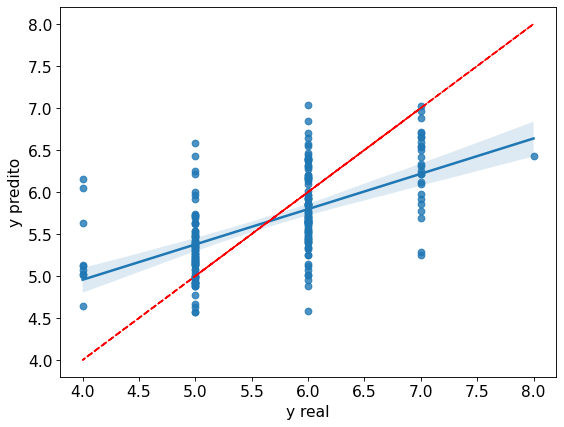

In [52]:
fig = plt.figure(figsize=(8, 6), dpi=80)
plt.rcParams.update({'font.size': 14})
ax = sns.regplot(x = y_test, y = y_pred)
ax.set(xlabel='y real', ylabel='y predito')
ax = plt.plot(y_test, y_test, '--r')

plt.savefig(FIGURES_DIR / "regressao_linear_real_vs_predito.png", bbox_inches="tight")
plt.show()


In [51]:
# Avaliando o modelo

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MAE', MAE)
print('MSE', MSE)
print('r2', r2)

MAE 0.4901854906188034
MSE 0.3999755694359135
r2 0.3256337034539979


In [ ]:
# A regressão linear foi testada como modelo baseline para prever a nota original de qualidade. 
# No entanto, como a variável quality é discreta e concentrada principalmente nas notas 5 e 6, 
# o modelo linear apresenta baixa capacidade de ajuste. Por isso, o problema será tratado 
# principalmente como classificação binária usando quality_binary.